In [3]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_1samp

In [12]:
# Setting up database
stocks_df = pd.read_csv("faang_stock_prices.csv")
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])

# Organization just in case of random unordered data. Initial csv seems to be ordered by date already
stocks_df = stocks_df.sort_values(by = "Date").dropna()

display(stocks_df)

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,2026-01-22,AAPL,249.199997,251.000000,248.149994,248.350006,39708300,253.921424,263.157615,256.309211,262.339803,11.871533,-6.030592,-4.355544,280.781111,244.752881,0.002827,0.013499,248.039993
14959,2026-01-22,AMZN,234.050003,235.720001,230.899994,234.339996,31913300,236.171426,236.013333,236.263937,235.039321,53.529872,1.224615,2.202436,248.520707,224.264292,0.013099,0.017721,239.160004
14960,2026-01-22,GOOGL,334.450012,335.149994,328.750000,330.540009,26253600,330.787144,321.977620,326.886086,320.764595,67.582193,6.121491,6.383337,339.589684,305.585319,0.006578,0.014879,327.929993
14961,2026-01-22,META,629.349976,660.570007,626.549988,647.630005,21394700,621.767151,645.427618,632.259363,640.510804,45.687381,-8.251442,-5.985550,684.649099,604.598899,0.056562,0.028988,658.760010


In [17]:
display(stocks_df.info())

<class 'pandas.DataFrame'>
Index: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             14964 non-null  datetime64[us]
 1   Ticker           14964 non-null  str           
 2   Open             14964 non-null  float64       
 3   High             14964 non-null  float64       
 4   Low              14964 non-null  float64       
 5   Close            14964 non-null  float64       
 6   Volume           14964 non-null  int64         
 7   SMA_7            14964 non-null  float64       
 8   SMA_21           14964 non-null  float64       
 9   EMA_12           14964 non-null  float64       
 10  EMA_26           14964 non-null  float64       
 11  RSI_14           14964 non-null  float64       
 12  MACD             14964 non-null  float64       
 13  MACD_Signal      14964 non-null  float64       
 14  Bollinger_Upper  14964 non-null  float64       
 15  B

None

**TEST 1: Checking The Mean Daily Return of AAPL Stock**

In [7]:
# First, we're gonna extract the data that we need.

aapl = stocks_df[stocks_df["Ticker"] == "AAPL"]["Daily_Return"]

Before we do a T-Test, let's list out the null and alternative hypothesis:

> Null Hypothesis: The mean daily return of the AAPL stock is 0.
> Alternative Hypothesis: The mean daily return of the AAPL stock differs from 0.

In [8]:
# Next, we're gonna do a T-Test on the returns for the AAPL stock.

t_stat, p_value = ttest_1samp(aapl, 0)

print("Mean Return: ", aapl.mean())
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

Mean Return:  0.001138375316073588
T-statistic:  3.12303182632681
P-value:  0.0018105315125036103


Based on the P-value of 0.0018, since this P-value is significantly smaller than the alpha level of 0.05 (0.0018 < 0.05), we reject the null hypothesis. This indicates that there is storng evidence th e mean daily return of AAPL is different from zero. Therefore, we can state that AAPL exhibits a statistically siginficant average return, suggesting the presence of a trend in returns rather than just stable at 0.

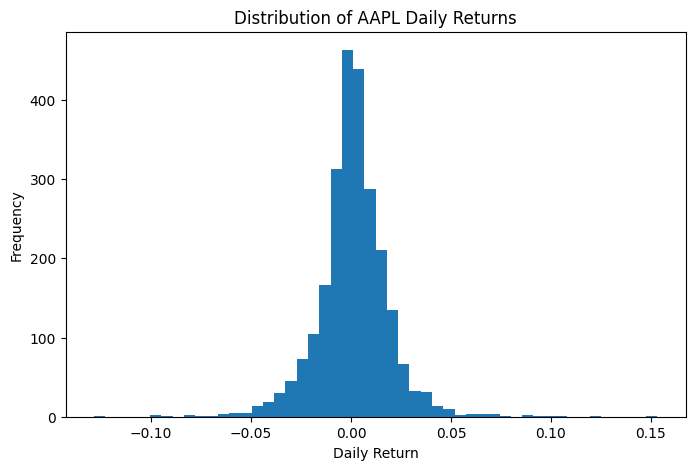

In [9]:
# Now, let's provide a plot to show this trend in average daily return.

plt.figure(figsize=(8,5))
plt.hist(aapl, bins = 50)

plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

Looking at the histogram distribution of daily returns for the AAPL stock, we see that it seems to be approximately centered around 0. Although this seems to visually be the case, the mean return is slightly different from zero based on the t-test (0.0011). The difference is too small to be visually noticeable on the histogram since there are so many samples. The larger the sample size, the smaller the difference from the null hypothesis to be significant, as more samples should theoretically allow us to get more accurate results. As a result, the test finds that the mean return is statistically significant despite looking close to 0 on the plot.